           monto  riesgo_hist  frecuencia_cliente
anomalía                                         
False     303.21         0.51               20.79
True      695.45         0.37               35.00


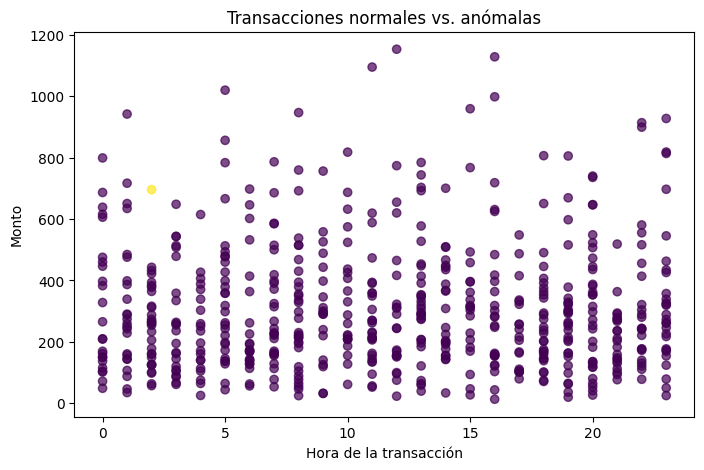

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 600
data = pd.DataFrame({
    "monto": np.random.gamma(shape=2, scale=150, size=n),               # importe de la transacción
    "origen": np.random.choice(["Local", "Extranjero"], size=n, p=[0.9, 0.1]),
    "hora": np.random.randint(0, 24, size=n),                           # hora del día
    "frecuencia_cliente": np.random.randint(1, 40, size=n),             # nº de transacciones recientes
    "riesgo_hist": np.random.uniform(0, 1, size=n)                      # score de riesgo histórico
})

# Regla heurística de anomalía:
#  - monto en el 8% superior de la distribución
#  - origen en el extranjero
#  - horario de madrugada (0 a 4 h)
umbral_monto = data["monto"].quantile(0.92)

data["anomalía"] = (
    (data["monto"] > umbral_monto) &
    (data["origen"] == "Extranjero") &
    (data["hora"].between(0, 4))
)

# Resumen numérico comparando transacciones normales vs. marcadas como anómalas
cols_num = ["monto", "riesgo_hist", "frecuencia_cliente"]

resumen_anomalias = (
    data
    .groupby("anomalía")[cols_num]
    .mean()
    .round(2)
)

print(resumen_anomalias)


plt.figure(figsize=(8, 5))
plt.scatter(
    data["hora"],
    data["monto"],
    c=data["anomalía"].astype(int),
    alpha=0.7
)
plt.xlabel("Hora de la transacción")
plt.ylabel("Monto")
plt.title("Transacciones normales vs. anómalas")
plt.show()

